First 5 rows:
                                              Product      Price  \
0  Dell Inspiron Core i3 10th Gen - (8 GB/1 TB HD...  Rs 39,990   
1  Lenovo Ideapad S145 APU Dual Core A6 - (4 GB/1...  Rs 22,990   
2  HP 15s Core i5 10th Gen - (8 GB/1 TB HDD/256 G...  Rs 53,990   
3  Asus VivoBook 14 Ryzen 5 Quad Core 2nd Gen - (...  Rs 42,990   
4  Lenovo Ideapad 3 Core i3 10th Gen - (4 GB/1 TB...  Rs 33,990   

                                   Processor            RAM  \
0         Intel Core i3 Processor (10th Gen)  8 GB DDR4 RAM   
1             AMD APU Dual Core A6 Processor  4 GB DDR4 RAM   
2         Intel Core i5 Processor (10th Gen)  8 GB DDR4 RAM   
3  AMD Ryzen 5 Quad Core Processor (2nd Gen)  8 GB DDR4 RAM   
4         Intel Core i3 Processor (10th Gen)  4 GB DDR4 RAM   

                     Operating System              Storage  \
0  64 bit Windows 10 Operating System             1 TB HDD   
1  64 bit Windows 10 Operating System             1 TB HDD   
2  64 bit Windows

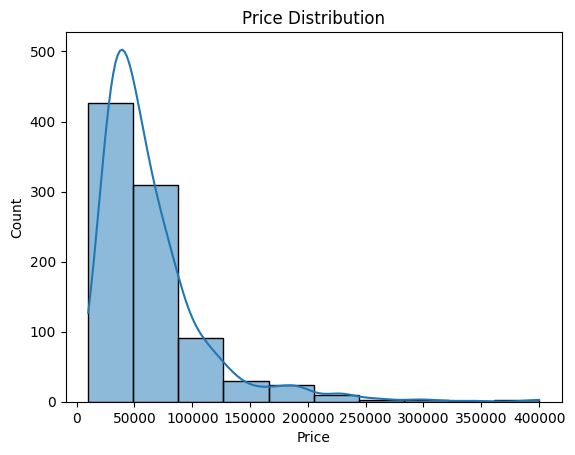

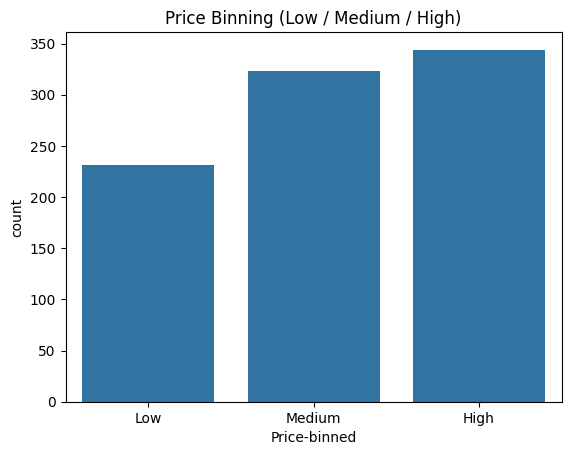

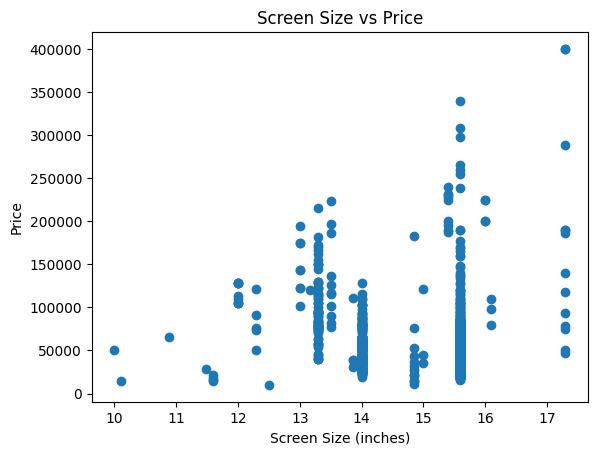

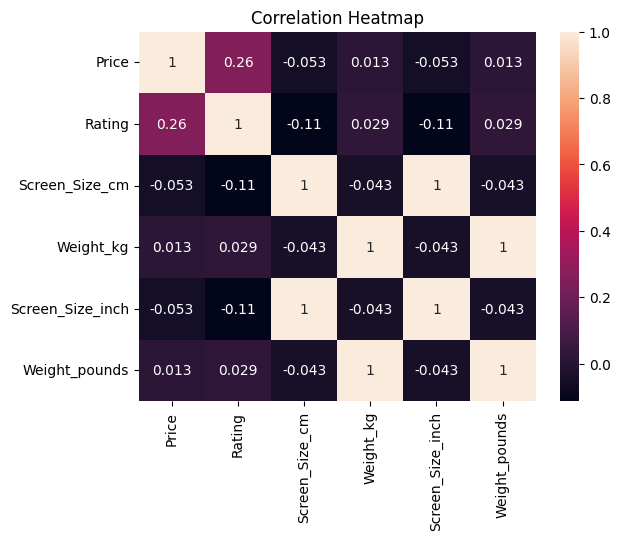

In [7]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("laptops.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

# ==============================
# 3. DATA CLEANING
# ==============================

# ---- Clean Price (remove Rs and commas) ----
df['Price'] = df['Price'].str.replace('Rs', '', regex=False)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(float)

# ---- Extract Screen Size in cm from Display ----
df['Screen_Size_cm'] = df['Display'].str.extract(r'(\d+\.\d+)').astype(float)

# ---- Create Weight column (since not present) ----
np.random.seed(0)
df['Weight_kg'] = np.random.uniform(1.2, 2.5, size=len(df))

# ==============================
# 4. HANDLE MISSING VALUES (FIXED)
# ==============================

print("\nMissing Values Before:\n", df.isnull().sum())

# Fill numeric columns with mean (NO chained assignment)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nMissing Values After:\n", df.isnull().sum())

# ==============================
# 5. UNIT CONVERSION
# ==============================

# cm → inches
df['Screen_Size_inch'] = df['Screen_Size_cm'] / 2.54

# kg → pounds
df['Weight_pounds'] = df['Weight_kg'] * 2.20462

# ==============================
# 6. PRICE BINNING
# ==============================

bins = [df['Price'].min(), 35000, 60000, df['Price'].max()]
labels = ['Low', 'Medium', 'High']

df['Price-binned'] = pd.cut(df['Price'], bins=bins, labels=labels, include_lowest=True)

# ==============================
# 7. CATEGORICAL → NUMERIC (Screen Type)
# ==============================

# Extract screen type
df['Screen'] = df['Display'].str.extract(r'(IPS|Full HD|Retina)', expand=False)

# One-hot encoding
df = pd.get_dummies(df, columns=['Screen'])

# ==============================
# 8. FINAL DATASET
# ==============================
print("\nFinal Dataset:\n", df.head())

# ==============================
# 9. IMPORTANT PLOTS
# ==============================

# ---- Price Distribution ----
plt.figure()
sns.histplot(df['Price'], bins=10, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# ---- Price Category Count ----
plt.figure()
sns.countplot(x='Price-binned', data=df)
plt.title("Price Binning (Low / Medium / High)")
plt.show()

# ---- Screen Size vs Price ----
plt.figure()
plt.scatter(df['Screen_Size_inch'], df['Price'])
plt.title("Screen Size vs Price")
plt.xlabel("Screen Size (inches)")
plt.ylabel("Price")
plt.show()

# ---- Correlation Heatmap ----
plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()